/tmp/ipykernel_8968/1264509362.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data = pd.read_csv('/content/archive (2).zip', parse_dates=['Date'])


Linear Trend: y = 1360.27 + 106.52x


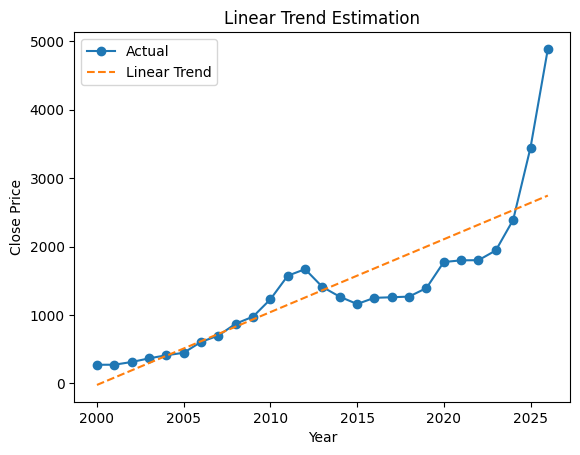

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
data = pd.read_csv('/content/archive (2).zip', parse_dates=['Date'])
data = data.sort_values('Date')
data['Year'] = data['Date'].dt.year
resampled_data = data.groupby('Year')['Close'].mean().to_frame()
resampled_data.reset_index(inplace=True)
years = resampled_data['Year'].tolist()
values = resampled_data['Close'].tolist()
X = [i - years[len(years)//2] for i in years]
x2 = [i**2 for i in X]
xy = [i*j for i, j in zip(X, values)]
n = len(years)
b = (n*sum(xy) - sum(values)*sum(X)) / (n*sum(x2) - (sum(X)**2))
a = (sum(values) - b*sum(X)) / n
linear_trend = [a + b*X[i] for i in range(n)]
print(f"Linear Trend: y = {a:.2f} + {b:.2f}x")
plt.figure()
plt.plot(years, values, marker='o', label='Actual')
plt.plot(years, linear_trend, linestyle='--', label='Linear Trend')
plt.title("Linear Trend Estimation")
plt.xlabel("Year")
plt.ylabel("Close Price")
plt.legend()
plt.show()

/tmp/ipykernel_8968/2624099215.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data = pd.read_csv('/content/archive (2).zip', parse_dates=['Date'])


Polynomial Trend: y = 1071.83 + 106.52x + 4.75x²


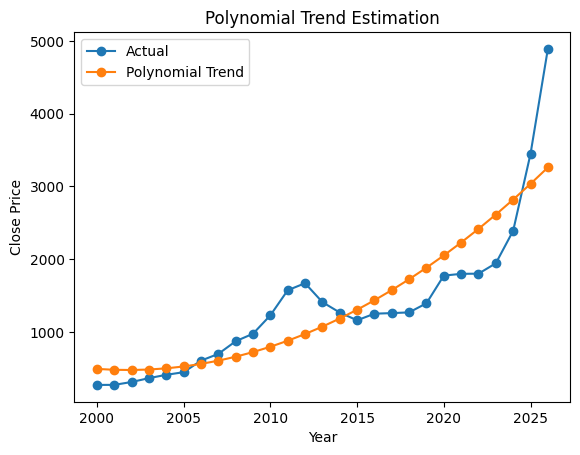

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
data = pd.read_csv('/content/archive (2).zip', parse_dates=['Date'])
data = data.sort_values('Date')
data['Year'] = data['Date'].dt.year
resampled_data = data.groupby('Year')['Close'].mean().to_frame()
resampled_data.reset_index(inplace=True)
years = resampled_data['Year'].tolist()
values = resampled_data['Close'].tolist()
X = [i - years[len(years)//2] for i in years]
x2 = [i**2 for i in X]
x3 = [i**3 for i in X]
x4 = [i**4 for i in X]

xy = [i*j for i, j in zip(X, values)]
x2y = [i*j for i, j in zip(x2, values)]

n = len(years)
coeff = [
    [n, sum(X), sum(x2)],
    [sum(X), sum(x2), sum(x3)],
    [sum(x2), sum(x3), sum(x4)]
]

Y = [sum(values), sum(xy), sum(x2y)]
A = np.array(coeff)
B = np.array(Y)

a, b, c = np.linalg.solve(A, B)
poly_trend = [a + b*X[i] + c*(X[i]**2) for i in range(n)]
print(f"Polynomial Trend: y = {a:.2f} + {b:.2f}x + {c:.2f}x²")
plt.figure()
plt.plot(years, values, marker='o', label='Actual')
plt.plot(years, poly_trend, marker='o', label='Polynomial Trend')
plt.title("Polynomial Trend Estimation")
plt.xlabel("Year")
plt.ylabel("Close Price")
plt.legend()
plt.show()